# LSST
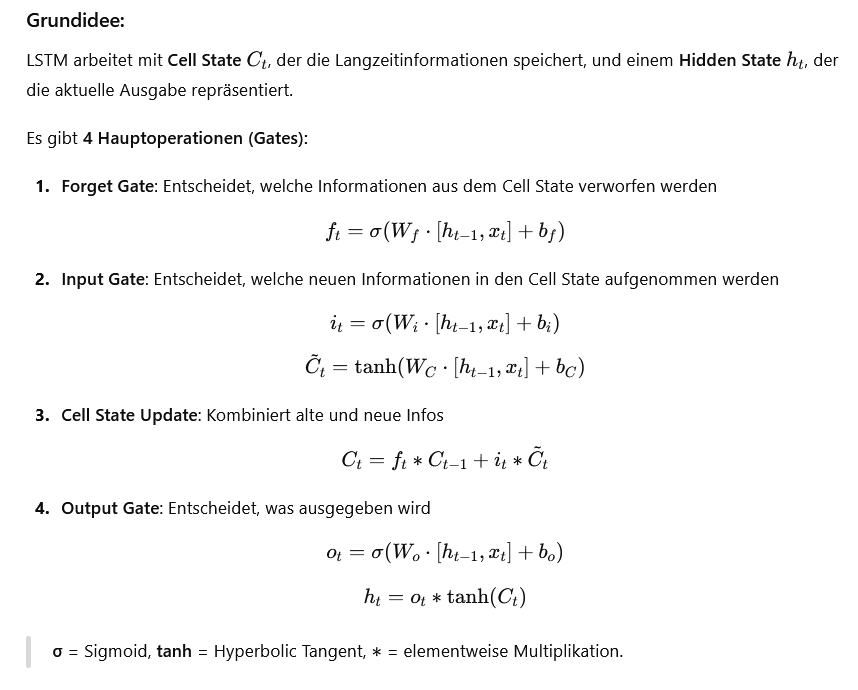

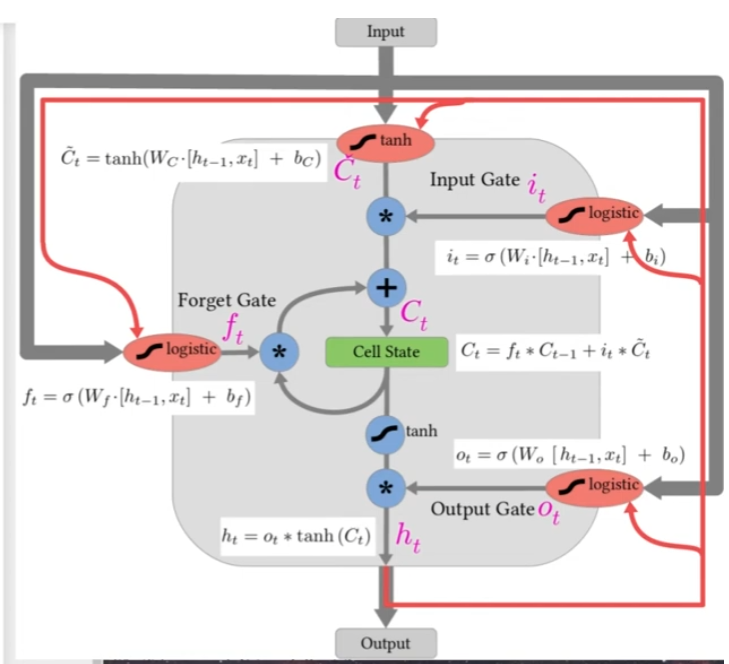


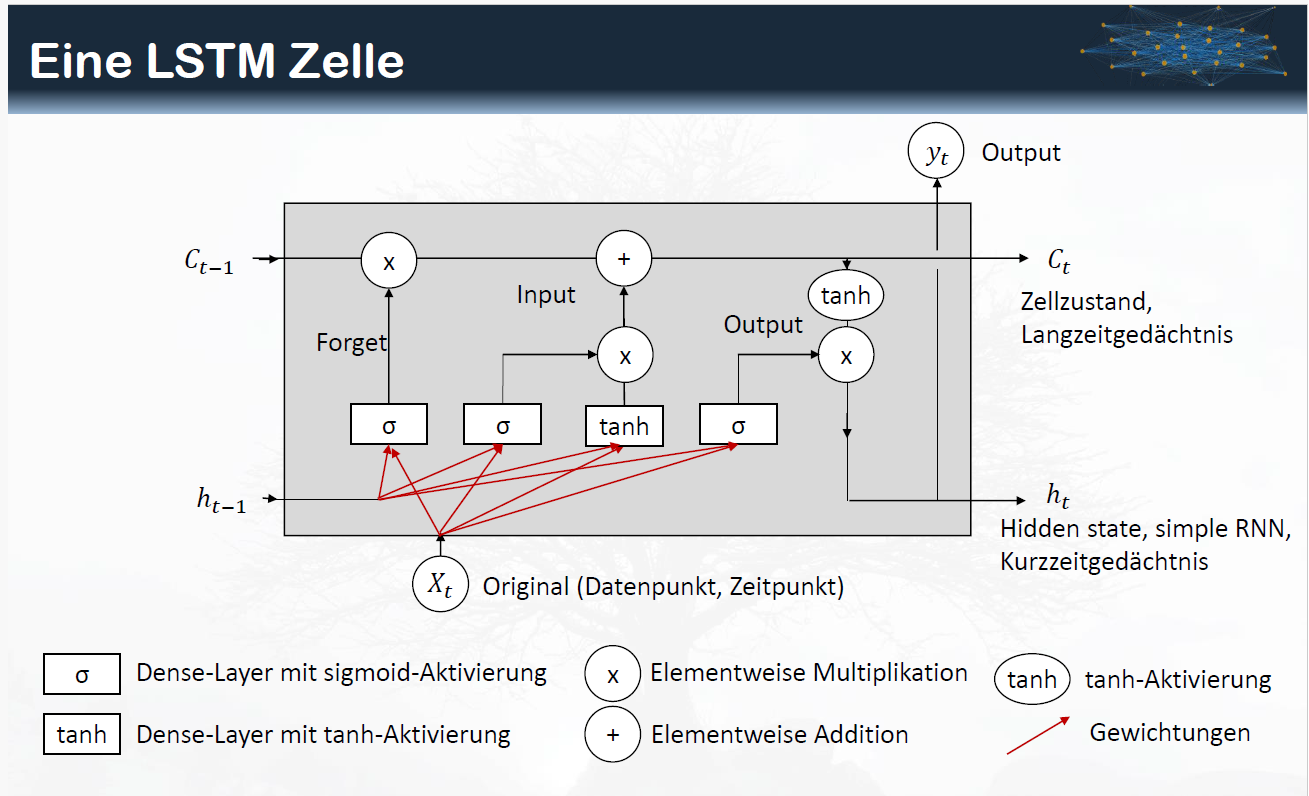





# Zahlenbeispiel mit Zwischenergebnissen

Angenommen:

Sequenzlänge = 3

Embedding = 2

Hidden1 = 2

Hidden2 = 2

# Beispiel 1:

In [3]:
import torch
import torch.nn as nn

x = torch.LongTensor([[2, 5, 3]])  # 1 Satz, 3 Wörter
embedding = nn.Embedding(6, 2, padding_idx=0)

# [batch, seq_len] -> [batch, seq_len, embed_dim].
# self.lstm1 = nn.LSTM(embed_dim, hidden1, batch_first=True)
lstm = nn.LSTM(2, 2, batch_first=True)

# Embedding
embedded = embedding(x)
print("Embedding:\n", embedded)

Embedding:
 tensor([[[-1.1397,  1.2602],
         [ 0.7390,  1.9542],
         [-0.7005, -0.4033]]], grad_fn=<EmbeddingBackward0>)


## Schritt 1: LSTM-Update für ersten Zeitschritt

In [4]:
out, (h_n, c_n) = lstm(embedded)
print("LSTM output:\n", out)
print("Final hidden state:\n", h_n)
print("Final cell state:\n", c_n)

LSTM output:
 tensor([[[ 0.2255,  0.0486],
         [ 0.1795, -0.0351],
         [ 0.1357, -0.0732]]], grad_fn=<TransposeBackward0>)
Final hidden state:
 tensor([[[ 0.1357, -0.0732]]], grad_fn=<StackBackward0>)
Final cell state:
 tensor([[[ 0.2382, -0.1111]]], grad_fn=<StackBackward0>)


In [5]:
pooled = torch.mean(out, dim=1)
print("Pooled:\n", pooled)

Pooled:
 tensor([[ 0.1802, -0.0199]], grad_fn=<MeanBackward1>)


In [6]:
fc = nn.Linear(2,1)
sigmoid = nn.Sigmoid()
output = sigmoid(fc(pooled))
print("Output probability:\n", output)

Output probability:
 tensor([[0.4817]], grad_fn=<SigmoidBackward0>)


# Beispiel 2

In [7]:
import torch
import torch.nn as nn

# -----------------------------
# Parameter
# -----------------------------
batch_size = 2
seq_len = 5
vocab_size = 10  # Beispielvokabular
embedding_dim = 3
hidden1 = 5
hidden2 = 6

# Dummy Input (2 Sätze, 5 Wörter pro Satz)
# Zahlen = Wort-IDs
x = torch.LongTensor([
    [2, 5, 3, 7, 1],
    [0, 4, 6, 2, 3]
])
print("Input word indices:\n", x)

# -----------------------------
# Embedding Layer
# -----------------------------
embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
embedded = embedding(x)
print("\nEmbedded vectors:\n", embedded)
print("Shape:", embedded.shape)  # [batch, seq_len, embed_dim]

# -----------------------------
# Erstes LSTM Layer
# -----------------------------
lstm1 = nn.LSTM(input_size=embedding_dim, hidden_size=hidden1, batch_first=True)
out1, (h1_n, c1_n) = lstm1(embedded)
print("\nLSTM1 Output (all timesteps):\n", out1)
print("Shape:", out1.shape)
print("LSTM1 Final hidden state h1_n:\n", h1_n)
print("LSTM1 Final cell state c1_n:\n", c1_n)

# -----------------------------
# Zweites LSTM Layer
# -----------------------------
lstm2 = nn.LSTM(input_size=hidden1, hidden_size=hidden2, batch_first=True)
out2, (h2_n, c2_n) = lstm2(out1)
print("\nLSTM2 Output (all timesteps):\n", out2)
print("Shape:", out2.shape)
print("LSTM2 Final hidden state h2_n:\n", h2_n)
print("LSTM2 Final cell state c2_n:\n", c2_n)

# -----------------------------
# Pooling (Mean über Sequenzlänge)
# -----------------------------
pooled = torch.mean(out2, dim=1)
print("\nPooled output (mean over sequence length):\n", pooled)
print("Shape:", pooled.shape)

# -----------------------------
# Fully Connected + Sigmoid
# -----------------------------
fc = nn.Linear(hidden2, 1)
sigmoid = nn.Sigmoid()
output = sigmoid(fc(pooled))
print("\nFinal output probabilities:\n", output)
print("Shape:", output.shape)

Input word indices:
 tensor([[2, 5, 3, 7, 1],
        [0, 4, 6, 2, 3]])

Embedded vectors:
 tensor([[[ 0.0163,  1.3530,  0.1621],
         [ 0.7992,  1.1419, -1.2122],
         [-0.8182, -0.8274,  1.5340],
         [-0.4694,  2.1106, -0.5129],
         [-0.1037,  0.8865,  0.6016]],

        [[ 0.0000,  0.0000,  0.0000],
         [-0.0775,  0.6758, -0.9085],
         [-1.0215, -1.8307, -2.6364],
         [ 0.0163,  1.3530,  0.1621],
         [-0.8182, -0.8274,  1.5340]]], grad_fn=<EmbeddingBackward0>)
Shape: torch.Size([2, 5, 3])

LSTM1 Output (all timesteps):
 tensor([[[-4.1466e-02,  3.8003e-02, -9.9440e-02, -9.8963e-02,  1.0004e-01],
         [-5.1518e-03,  1.9064e-02, -7.3746e-02, -7.1634e-02,  7.4695e-02],
         [-2.8090e-01,  1.8847e-02, -1.5469e-01, -1.1451e-01,  1.4673e-02],
         [-5.1061e-02, -1.3454e-04, -1.4977e-01, -1.7273e-01,  1.0970e-01],
         [-1.3248e-01,  3.1067e-02, -1.6828e-01, -1.9129e-01,  1.7263e-01]],

        [[-9.2711e-02,  5.1258e-03, -6.8565e-02, -2

# Beispiel 3

In [8]:
# -*- coding: utf-8 -*-
import torch
import torch.nn as nn

# =========================
# 1️⃣ Parameter & Dummy Daten
# =========================
batch_size = 2
seq_len = 5
vocab_size = 10   # Beispiel-Vokabular: IDs 0..9
embedding_dim = 3
hidden1 = 5
hidden2 = 6

# Dummy-Sätze (Batch_size=2, Sequenzlänge=5)
# Werte = Wort-IDs (0 = <pad>, 1..9 = Wörter)
X = torch.LongTensor([
    [2, 4, 5, 1, 0],   # Satz 1
    [3, 1, 7, 2, 5]    # Satz 2
])
print("Input IDs:\n", X, "\n")

# =========================
# 2️⃣ Embedding Layer
# =========================
embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
embedded = embedding(X)
print("Embedded vectors (Shape: [batch, seq_len, embed_dim]):\n", embedded, "\n")

# =========================
# 3️⃣ LSTM Layer 1
# =========================
lstm1 = nn.LSTM(input_size=embedding_dim, hidden_size=hidden1, batch_first=True)
out1, (h_n1, c_n1) = lstm1(embedded)
print("LSTM1 output (all hidden states):\n", out1, "\n")
print("LSTM1 final hidden state h_n1:\n", h_n1, "\n")
print("LSTM1 final cell state c_n1:\n", c_n1, "\n")

# =========================
# 4️⃣ LSTM Layer 2
# =========================
lstm2 = nn.LSTM(input_size=hidden1, hidden_size=hidden2, batch_first=True)
out2, (h_n2, c_n2) = lstm2(out1)
print("LSTM2 output (all hidden states):\n", out2, "\n")
print("LSTM2 final hidden state h_n2:\n", h_n2, "\n")
print("LSTM2 final cell state c_n2:\n", c_n2, "\n")

# =========================
# 5️⃣ Mean Pooling über Sequenzlänge
# =========================
pooled = torch.mean(out2, dim=1)  # [batch, hidden2]
print("Pooled hidden states (Mean over seq_len):\n", pooled, "\n")

# =========================
# 6️⃣ Fully Connected + Sigmoid
# =========================
fc = nn.Linear(hidden2, 1)
sigmoid = nn.Sigmoid()
output = sigmoid(fc(pooled))
print("Output probability per sentence:\n", output, "\n")

# =========================
# 7️⃣ Zusammenfassung Shapes
# =========================
print(f"Shapes:")
print(f"  Input IDs: {X.shape}")
print(f"  Embedded: {embedded.shape}")
print(f"  LSTM1 out: {out1.shape}")
print(f"  LSTM1 h_n: {h_n1.shape}, c_n: {c_n1.shape}")
print(f"  LSTM2 out: {out2.shape}")
print(f"  LSTM2 h_n: {h_n2.shape}, c_n: {c_n2.shape}")
print(f"  Pooled: {pooled.shape}")
print(f"  Output: {output.shape}")

Input IDs:
 tensor([[2, 4, 5, 1, 0],
        [3, 1, 7, 2, 5]]) 

Embedded vectors (Shape: [batch, seq_len, embed_dim]):
 tensor([[[ 0.4292,  1.3974,  1.6232],
         [-0.2185, -1.3232, -0.3190],
         [ 0.5814, -0.5214,  0.7161],
         [-0.2790,  0.6655,  0.3356],
         [ 0.0000,  0.0000,  0.0000]],

        [[-0.3601, -0.4396,  0.9636],
         [-0.2790,  0.6655,  0.3356],
         [ 0.2382, -2.0021, -0.1062],
         [ 0.4292,  1.3974,  1.6232],
         [ 0.5814, -0.5214,  0.7161]]], grad_fn=<EmbeddingBackward0>) 

LSTM1 output (all hidden states):
 tensor([[[-0.1480,  0.0652,  0.1074, -0.0005, -0.2551],
         [-0.1324,  0.1802, -0.1069,  0.0062, -0.1882],
         [-0.1036,  0.1939, -0.0908, -0.0079, -0.3264],
         [-0.1289,  0.2015,  0.0287, -0.0238, -0.2792],
         [-0.1133,  0.2739,  0.0472, -0.0520, -0.2547]],

        [[-0.0469, -0.0031, -0.2068,  0.0622, -0.2378],
         [-0.1091,  0.1068, -0.0571,  0.0215, -0.2531],
         [ 0.0119,  0.1324, -0.191